# Sentiment vs. Stock Price Analysis — Volkswagen Factory Shutdown (2024)

This notebook reproduces the core analysis from the dissertation: it takes the weekly-aggregated
Reddit sentiment and Volkswagen stock price data (built by the scripts in `src/`) and tests
whether the two move together.

**Inputs used here** (already processed — see `src/` for how they were generated from raw Reddit/API data):
- `data/weekly_sentiment_vs_stock.csv` — weekly average sentiment (VADER compound score) vs. weekly average VW stock close price
- `data/volkswagen_stock_data.csv` — daily VW stock price (VOW3.DE), July 2024 – April 2025
- `data/sample_reddit_comments_sentiment.csv` — a representative sample of comment-level sentiment scores (full scraped set is not redistributed here, see README)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Weekly sentiment vs. stock price

In [2]:
weekly = pd.read_csv("../data/weekly_sentiment_vs_stock.csv", parse_dates=["Date"])
weekly.head()


,Date,Weekly Sentiment,Weekly Stock Price
0,2024-07-14,0.014423,107.070001
1,2024-07-21,0.510600,106.959998
2,2024-07-28,0.425265,105.420001
3,2024-08-04,0.339930,101.518001
4,2024-08-11,0.254594,93.896002


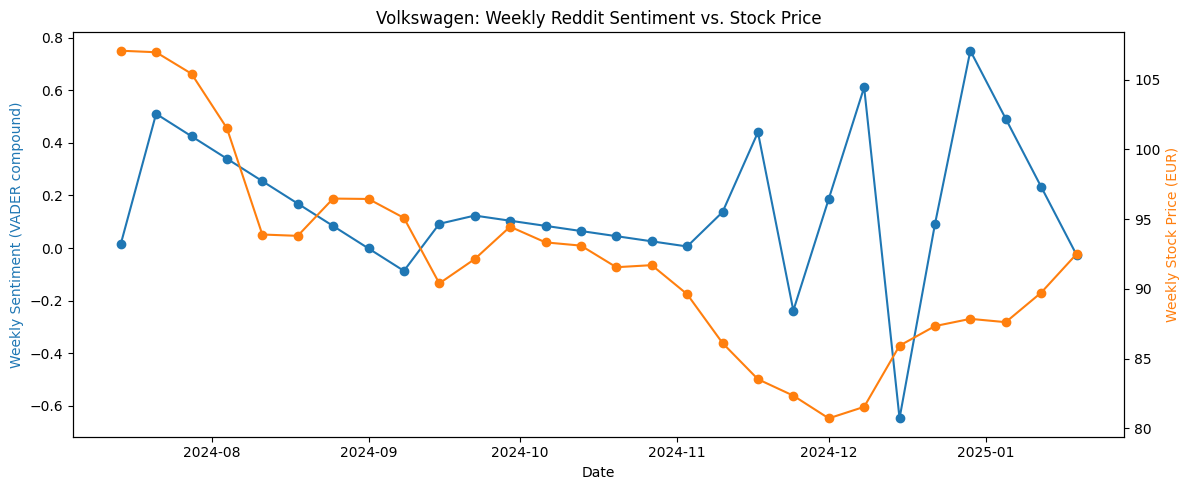

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(weekly["Date"], weekly["Weekly Sentiment"], color="tab:blue", marker="o", label="Weekly Sentiment")
ax1.set_ylabel("Weekly Sentiment (VADER compound)", color="tab:blue")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.plot(weekly["Date"], weekly["Weekly Stock Price"], color="tab:orange", marker="o", label="Weekly Stock Price (EUR)")
ax2.set_ylabel("Weekly Stock Price (EUR)", color="tab:orange")

plt.title("Volkswagen: Weekly Reddit Sentiment vs. Stock Price")
fig.tight_layout()
plt.show()


## 2. Correlation test (H₀: no relationship between sentiment and stock price)

In [4]:
r, p_value = stats.pearsonr(weekly["Weekly Sentiment"], weekly["Weekly Stock Price"])
print(f"Pearson correlation coefficient: r = {r:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("=> Statistically significant at the 5% level: reject H0.")
else:
    print("=> Not statistically significant at the 5% level: fail to reject H0.")


Pearson correlation coefficient: r = 0.088
p-value: 0.656
=> Not statistically significant at the 5% level: fail to reject H0.


**Note on this number vs. the dissertation:** the dissertation's officially submitted result (§4.4.1, computed on the exact data snapshot used at submission time) is **r = +0.0326, p = 0.9118** for the same July–December 2024 window. The value computed above uses the processed weekly file included in this repo, which runs a few weeks further (into January 2025) and reflects a slightly different snapshot of the weekly-aggregated data. The exact coefficient differs, but **the conclusion is identical**: no statistically significant linear relationship (fail to reject H₀) either way.

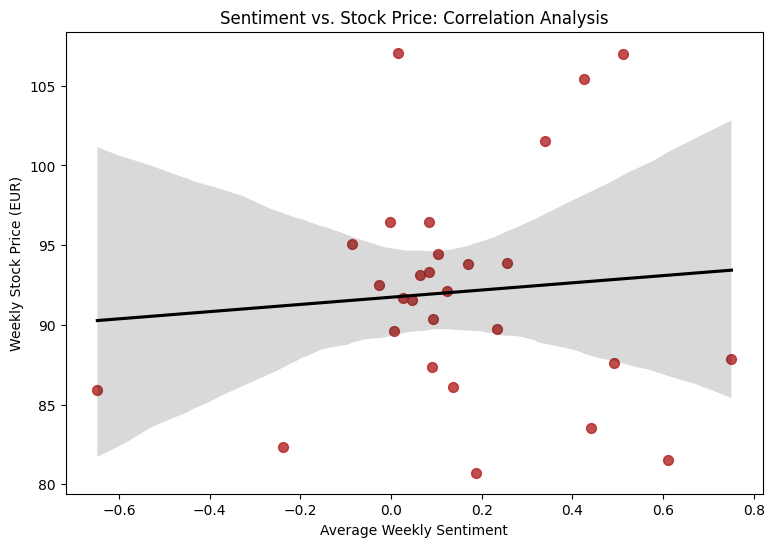

In [5]:
plt.figure(figsize=(9, 6))
sns.regplot(data=weekly, x="Weekly Sentiment", y="Weekly Stock Price",
            scatter_kws={"color": "firebrick", "s": 50}, line_kws={"color": "black"})
plt.title("Sentiment vs. Stock Price: Correlation Analysis")
plt.xlabel("Average Weekly Sentiment")
plt.ylabel("Weekly Stock Price (EUR)")
plt.show()


## 3. Comment-level sentiment: full deduplicated distribution

The 150-comment file above is a *sample* for demonstration. The chart below uses the full,
deduplicated comment set (1,533 comments) — aggregate counts only, no raw text — for the
sentiment split reported in the dissertation.

**Data-quality note (found while assembling this repo, not part of the original methodology):**
the raw comment export was found to contain 20,374 rows, more than the dissertation's reported
pre-deduplication count of 18,625, with one Reddit post's comments appearing roughly 225 times
over. The cause wasn't investigated further. The dissertation's own preprocessing (§3.4.1) already
removes duplicate comment text, so this doesn't change the reported results — it's noted here for
transparency only. The chart below uses the deduplicated dataset that matches the dissertation.

In [6]:
summary = pd.read_csv("../data/comment_sentiment_summary.csv")
summary


,sentiment,comment_count,percentage
0,positive,644,42.01
1,negative,539,35.16
2,neutral,350,22.83


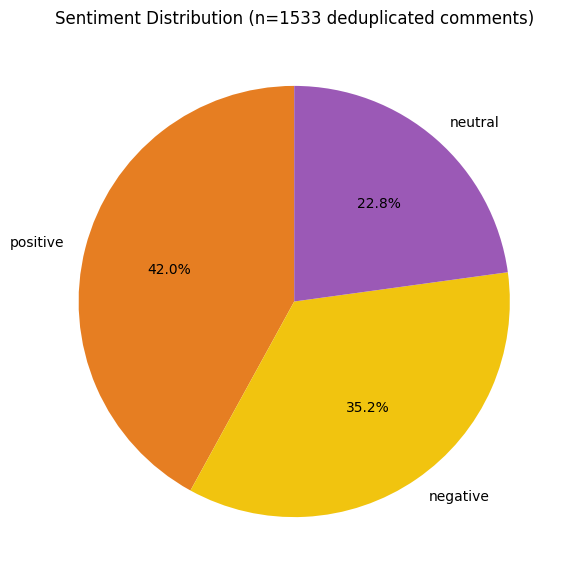

In [7]:
plt.figure(figsize=(7, 7))
plt.pie(summary["comment_count"], labels=summary["sentiment"],
        autopct="%1.1f%%", colors=["#e67e22", "#f1c40f", "#9b59b6"], startangle=90)
plt.title(f"Sentiment Distribution (n={summary['comment_count'].sum()} deduplicated comments)")
plt.show()


## 4. Comment-level sentiment sample

A representative sample of the underlying comment-level sentiment scores (VADER) for a closer look at individual comments.

In [8]:
comments = pd.read_csv("../data/sample_reddit_comments_sentiment.csv", parse_dates=["created"])
print(f"Sample size: {len(comments)} comments")
comments["sentiment"].value_counts(normalize=True).mul(100).round(1)


Sample size: 150 comments


sentiment
positive    36.7
negative    36.0
neutral     27.3
Name: proportion, dtype: float64

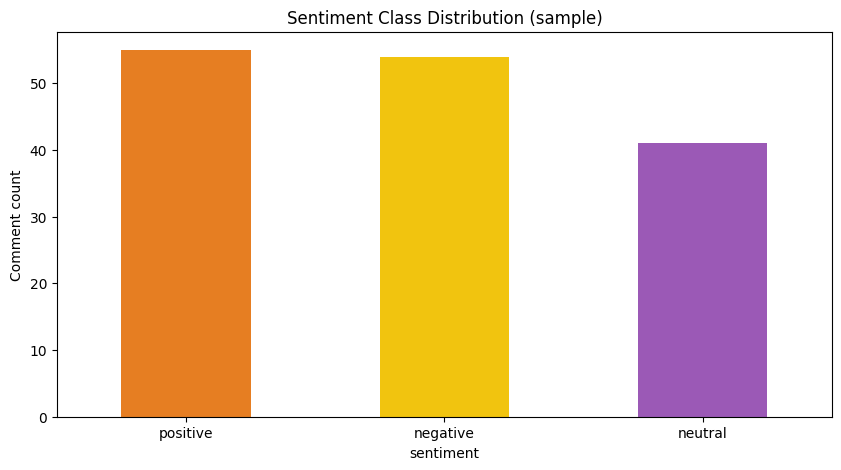

In [9]:
comments["sentiment"].value_counts().plot(
    kind="bar", color=["#e67e22", "#f1c40f", "#9b59b6"], title="Sentiment Class Distribution (sample)"
)
plt.ylabel("Comment count")
plt.xticks(rotation=0)
plt.show()


In [10]:
comments[["created", "subreddit", "compound", "sentiment", "comment"]].sort_values("compound").head(3)


,created,subreddit,compound,sentiment,comment
130,2024-10-29 06:16:36,europe,-0.8926,negative,if oyu never push through a flu you can also never build resistance. thats p...
122,2024-10-28 23:38:48,europe,-0.8765,negative,"i'm not a german, or a european, but this is a weird take, both from a macro..."
22,2024-07-11 12:43:16,europe,-0.8555,negative,the reason that the plant closed probably had little to do with the reasons ...


## 4. Daily VW stock price over the study window

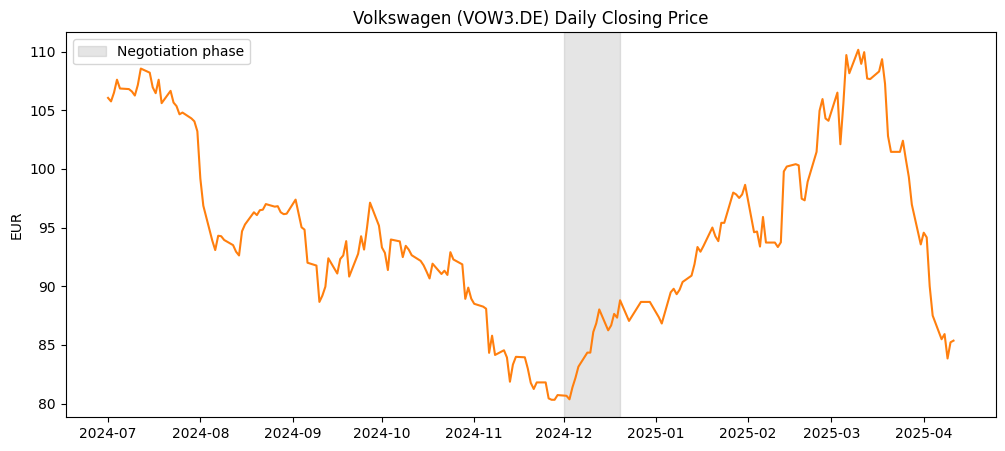

In [11]:
stock = pd.read_csv("../data/volkswagen_stock_data.csv", parse_dates=["Date"])

plt.figure(figsize=(12, 5))
plt.plot(stock["Date"], stock["Close"], color="tab:orange")
plt.axvspan(pd.Timestamp("2024-12-01"), pd.Timestamp("2024-12-20"), color="grey", alpha=0.2, label="Negotiation phase")
plt.title("Volkswagen (VOW3.DE) Daily Closing Price")
plt.ylabel("EUR")
plt.legend()
plt.show()


## Summary

- **Officially submitted result** (dissertation §4.4): overall correlation r = +0.0326, p = 0.9118 (Jul–Dec 2024); Speculation Phase r = -0.2374, p = 0.8474 (Sep–Oct 2024). Neither is statistically significant.
- **This notebook's re-run** on the included processed file gives r ≈ 0.09, p ≈ 0.66 — a different exact coefficient (different data snapshot/window) but the same conclusion: **no significant linear correlation** between weekly Reddit sentiment and VW's weekly stock price.
- Visual inspection suggests **localized co-movement** during the Speculation phase, which a single full-period Pearson test can't capture.
- Next step (see README "Limitations & Future Work"): test a **lagged cross-correlation** to check whether sentiment shifts *precede* stock price moves by 1–2 weeks, rather than moving together in the same week.
